In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="numpy.dtype size changed")

import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
dyn.pl.style(font_path='Arial')

Using already downloaded Arial font from: /var/folders/_0/8l2kpxvj13b9xcgqzjm3mkjw0000gn/T/dynamo_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered custom font as: Arial


 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

In [3]:
adata_36=dyn.read_h5ad('results/adata_nmda36_dynamo.h5ad')

In [13]:
adata_72=dyn.read_h5ad('results/adata_nmda72_dynamo.h5ad')

In [7]:
adata_96=dyn.read_h5ad('results/adata_nmda96_dynamo.h5ad')

In [8]:
color_key_dict = {
    'Progenitor': '#00CED1',  
    'Amacrine': '#E31A1C',
    'Bipolar': '#A6D854',   
    'Rod': '#FDBF6F',        
    'Müller': '#1F78B4',   
    'Ganglion': '#FB9A99',   
    'Horizontal': '#6A3D9A',  
    'RPE': '#B15928',         
    'Red Cone': '#FF0000',   
    'Green Cone': '#00FF00', 
    'Blue Cone': '#0000FF',   
    'UV Cone': '#9400D3',     
    'Macrophage': '#FF00FF'    
}

In [9]:
def velocity(query_pos, vf):
    # Euclidean distance squared
    dist_sq = np.sum(query_pos**2, axis=1).reshape(-1, 1) + np.sum(vf['X_ctrl']**2, axis=1) - 2 * np.dot(query_pos, vf['X_ctrl'].T)
    
    # Gaussian kernel
    K = np.exp(-vf['beta'] * dist_sq)
    
    # Velocity at query point
    V = np.dot(K, vf['C'])
    
    return V

def simulate_paths(init_pos, vf_start, vf_end, dt):
    traj = [init_pos]
    current_pos = np.copy(init_pos)

    for i in range(100): # Interporlate over 100 steps
        s = i / 100
        
        # get velocity from the starting and ending timepoint models
        v_start = velocity(current_pos, vf_start)
        v_end = velocity(current_pos, vf_end)
        
        v_interp = (1 - s) * v_start + s * v_end

        current_pos += v_interp * dt
        traj.append(np.copy(current_pos))
        
    return np.array(traj)

|-----------> plotting with basis key=X_umap
|-----------> skip filtering Cell_type by stack threshold when stacking color because it is not a numeric type


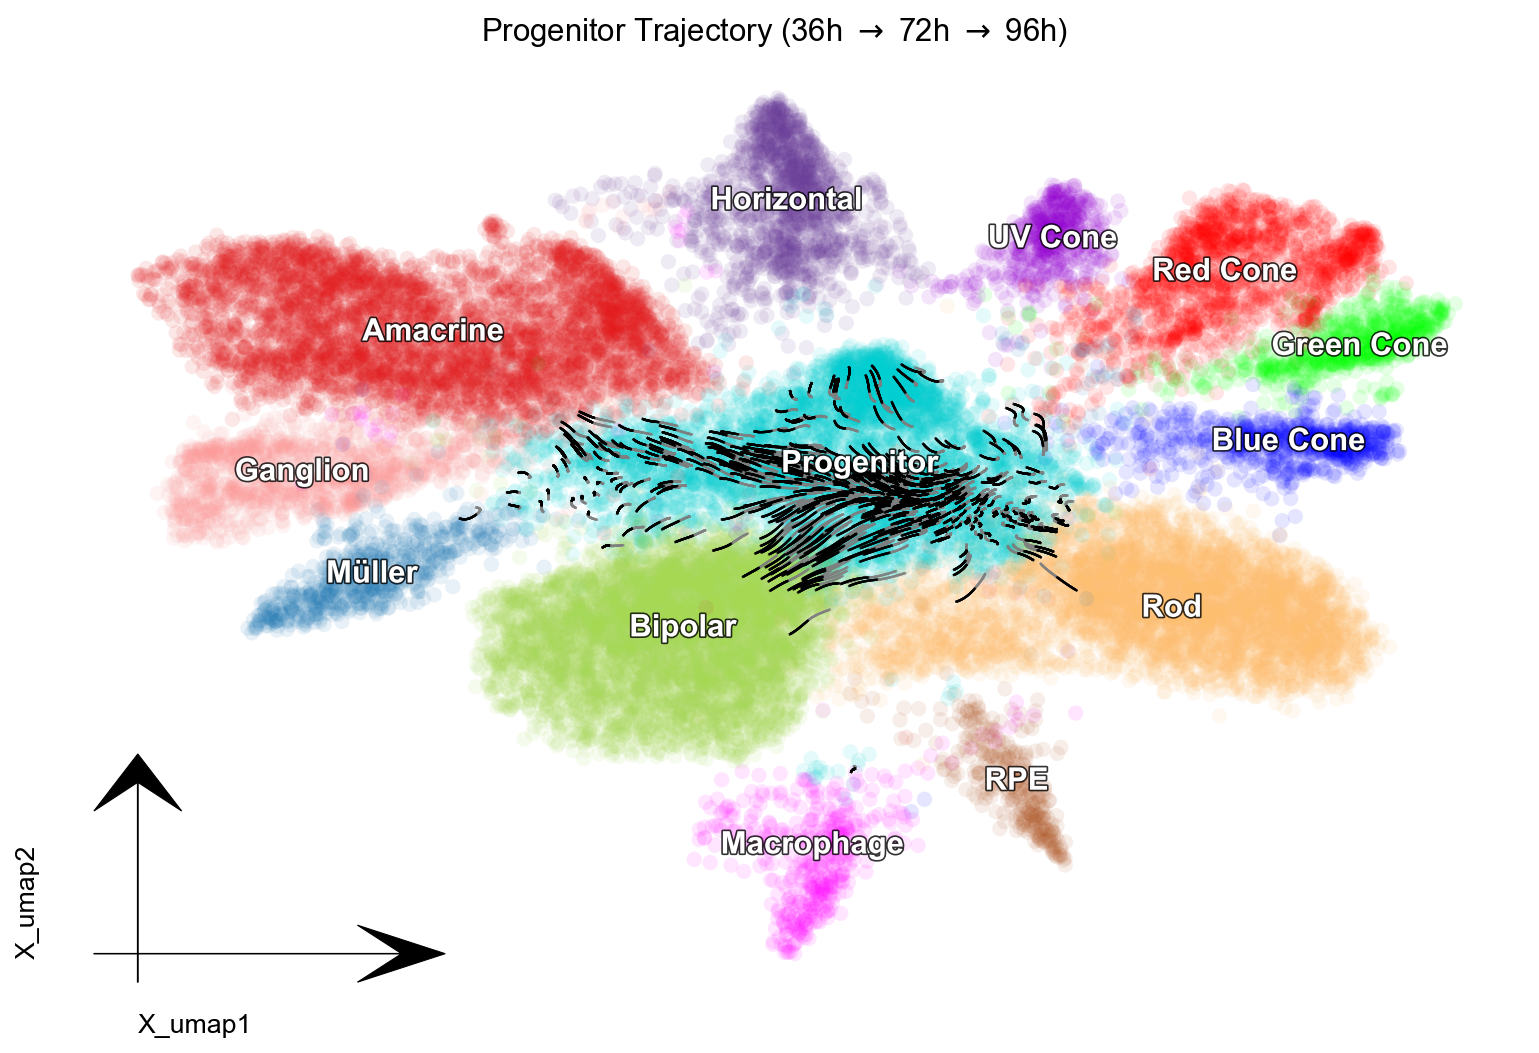

In [10]:
adata_36_prog = adata_36[adata_36.obs['Cell_type'] == 'Progenitor']
progenitor_indices = np.random.choice(adata_36_prog.n_obs, 500, replace=False)
progenitors = adata_36_prog.obsm['X_umap'][progenitor_indices]

paths1 = simulate_paths(
    progenitors, 
    adata_36.uns['VecFld_umap'], 
    adata_72.uns['VecFld_umap'],
    dt=0.01 * 1.11)

fig, ax = plt.subplots(figsize=(12, 8))

paths2 = simulate_paths(
    paths1[-1], 
    adata_72.uns['VecFld_umap'], 
    adata_96.uns['VecFld_umap'],
    dt=0.01 * 1.21)

dyn.pl.umap(adata_96, color='Cell_type', color_key=color_key_dict, ax=ax, alpha=0.1, pointsize=0.5, save_show_or_return='return')

for t in range(100):
    ax.plot(
        [paths1[t, :, 0], paths1[t+1, :, 0]], 
        [paths1[t, :, 1], paths1[t+1, :, 1]], 
        color='#808080', 
        alpha=0.3, 
        linewidth=1.0
    )

n_steps_2 = paths2.shape[0]
for t in range(n_steps_2 - 1):
    ax.plot(
        [paths2[t, :, 0], paths2[t+1, :, 0]], 
        [paths2[t, :, 1], paths2[t+1, :, 1]], 
        color='black', 
        alpha=0.4, 
        linewidth=1.0
    )

ax.set_title("Progenitor Trajectory (36h $\\rightarrow$ 72h $\\rightarrow$ 96h)")
plt.show()

In [11]:
start = paths1[0, :, :]
end = paths2[-1, :, :]

# compute centers of amacirne and bipolar clusters in the 96h dataset
X_umap = adata_96.obsm['X_umap']
cell_type = adata_96.obs['Cell_type'].astype(str).values
amacrine_center = np.median(X_umap[(cell_type == 'Amacrine')], axis=0)
bipolar_center = np.median(X_umap[(cell_type == 'Bipolar')], axis=0)

# compute how closer they came to amacirne/bipolar centers
start_to_amacrine = np.linalg.norm(start - amacrine_center, axis=1)
end_to_amacrine = np.linalg.norm(end - amacrine_center, axis=1)
start_to_bipolar = np.linalg.norm(start - bipolar_center, axis=1)
end_to_bipolar = np.linalg.norm(end - bipolar_center, axis=1)

delta_amacrine = end_to_amacrine - start_to_amacrine
delta_bipolar = end_to_bipolar  - start_to_bipolar

commitment = []
for i in range (500):
    if delta_amacrine[i] < delta_bipolar[i]: # came closer to amacrine than bipolar
        commitment.append('Amacrine-commiting progenitors')
    else:
        commitment.append('Bipolar-commiting progenitors')

commitment = np.array(commitment)

progenitors_df = pd.DataFrame({
    'UMAP_1': start[:, 0],
    'UMAP_2': start[:, 1],
    'Commitment': commitment
})

print(progenitors_df.groupby('Commitment').size())

Commitment
Amacrine-commiting progenitors    268
Bipolar-commiting progenitors     232
dtype: int64


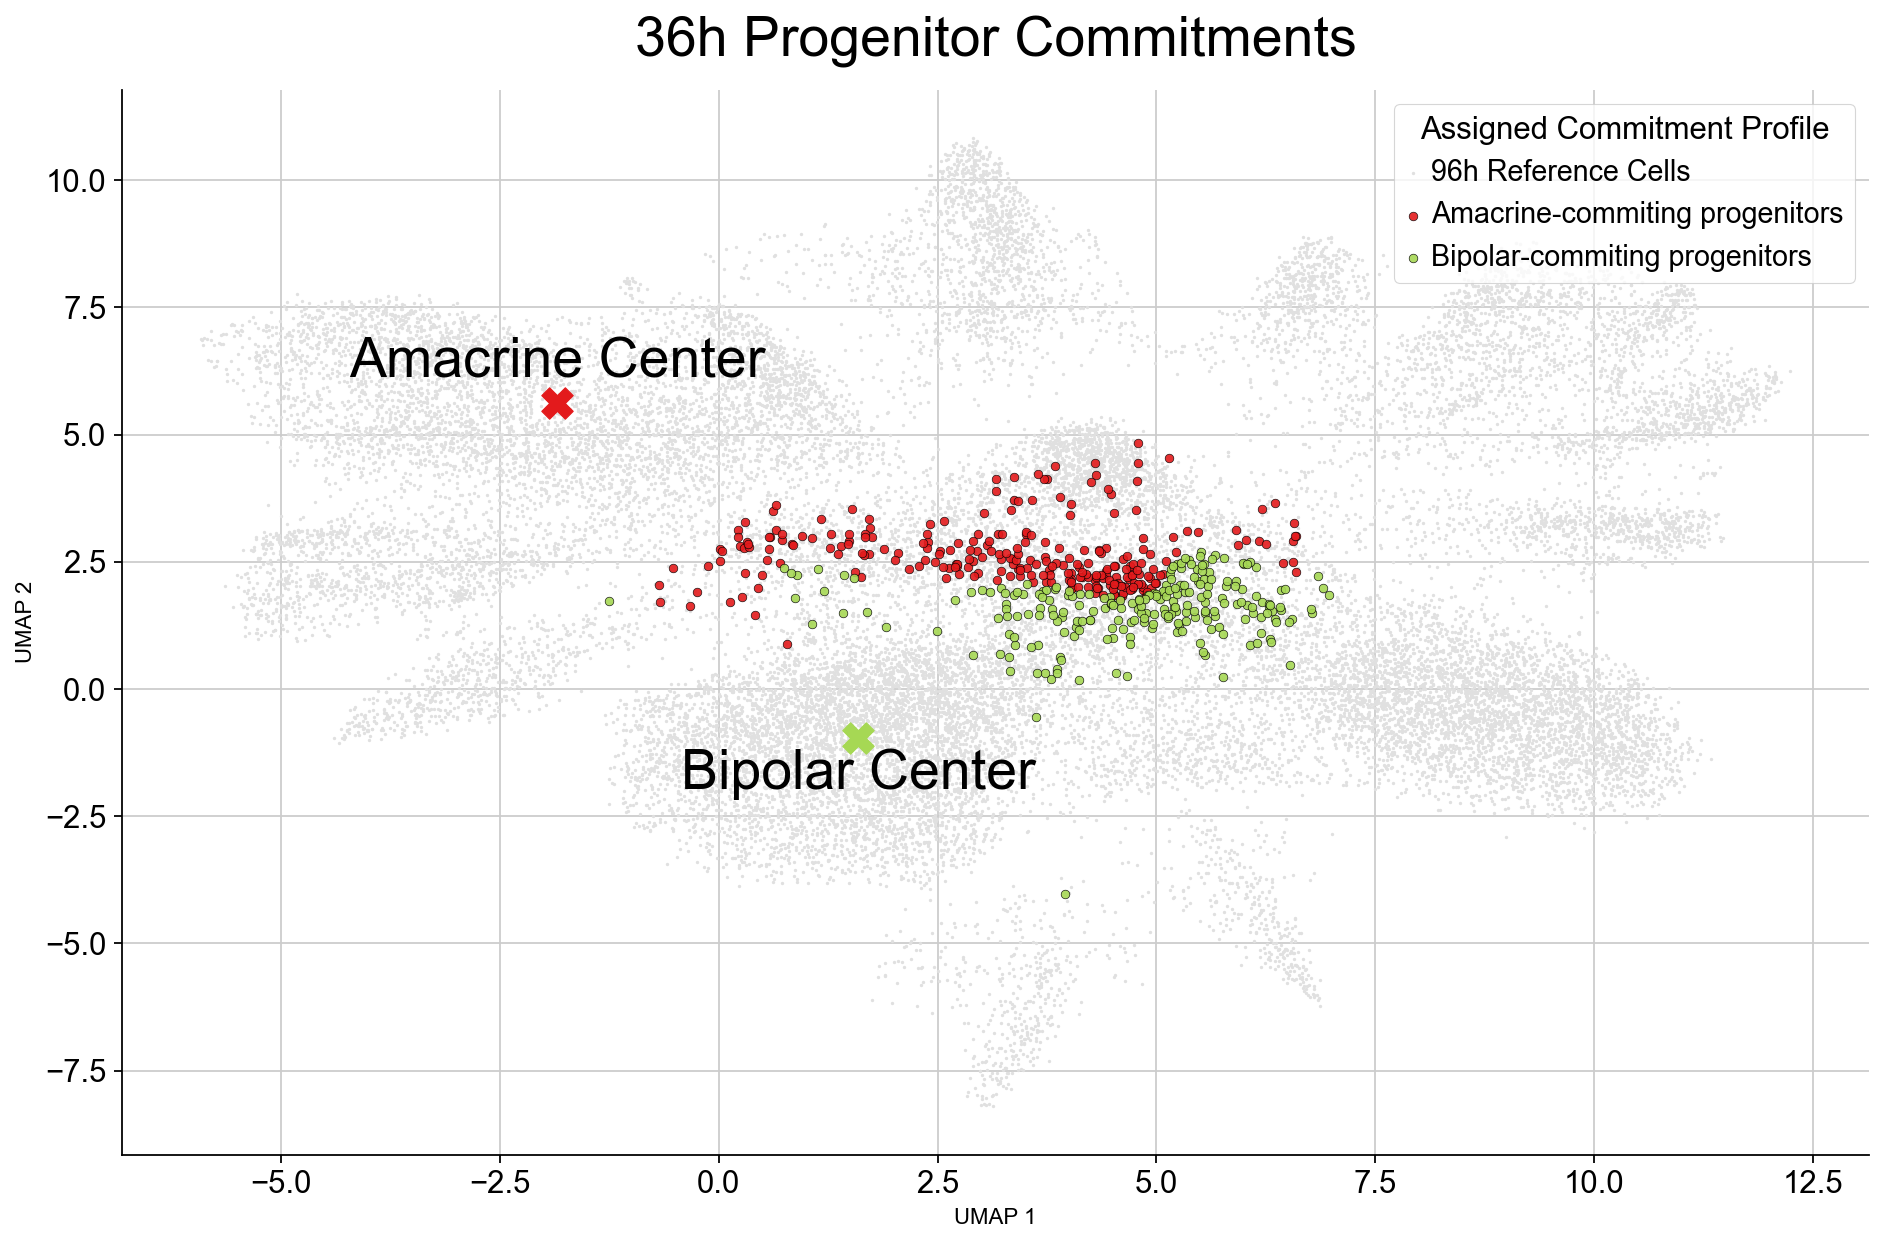

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(X_umap[:, 0], X_umap[:, 1], color='#e0e0e0', s=1, alpha=1, zorder=1, label='96h Reference Cells')

color_map = {
    'Amacrine-commiting progenitors': '#E31A1C',
    'Bipolar-commiting progenitors': '#A6D854',
}

for fate, color in color_map.items():
    mask = progenitors_df['Commitment'] == fate
    subset = progenitors_df[mask]
    
    ax.scatter(subset['UMAP_1'], subset['UMAP_2'], color=color, s=15, edgecolor='black', linewidth=0.3, alpha=0.9, zorder=2, label=fate)

ax.scatter(amacrine_center[0], amacrine_center[1], c='#E31A1C', marker='X', s=200, zorder=3)
ax.scatter(bipolar_center[0], bipolar_center[1], c='#A6D854', marker='X', s=200, zorder=3)
ax.text(amacrine_center[0], amacrine_center[1] + 0.5, 'Amacrine Center', fontsize=25, ha='center', zorder=4)
ax.text(bipolar_center[0], bipolar_center[1] - 1, 'Bipolar Center', fontsize=25, ha='center', zorder=4)

ax.set_title("36h Progenitor Commitments", fontsize=25, pad=15)
ax.set_xlabel("UMAP 1", fontsize=10)
ax.set_ylabel("UMAP 2", fontsize=10)
ax.legend(loc='upper right', title='Assigned Commitment Profile', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
adata_36_start = adata_36[progenitor_indices.astype(int)]
adata_36_start.obs['Commitment'] = progenitors_df['Commitment'].values
adata_36_start.obs['Commitment'] = adata_36_start.obs['Commitment'].astype('category')
adata_36_start.X = adata_36_start.X.toarray()

sc.tl.rank_genes_groups(adata_36_start, groupby='Commitment', method='wilcoxon')

In [11]:
sc.get.rank_genes_groups_df(adata_36_start, group="Amacrine-commiting progenitors").head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,rps13,2.276926,0.412189,0.022791,1.0
1,hmgn2,2.241858,0.438116,0.024971,1.0
2,rps10,2.151551,0.360079,0.031433,1.0
3,rbp5,2.150309,0.872189,0.031531,1.0
4,ankrd11,2.108414,0.683826,0.034995,1.0
5,serinc4,2.066519,0.766646,0.038780,1.0
6,naca,2.001659,0.512691,0.045321,1.0
7,rplp2,1.977143,0.322697,0.048026,1.0
8,guca1aa,1.942075,0.750508,0.052128,1.0
9,cirbpa,1.935558,0.435527,0.052922,1.0


In [12]:
sc.get.rank_genes_groups_df(adata_36_start, group="Bipolar-commiting progenitors").head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,opn1lw1,3.088141,0.355799,0.002014,1.0
1,arr3a,2.482678,0.476483,0.013040,1.0
2,rpl3,2.372509,0.405825,0.017668,1.0
3,cox7b,2.355441,0.613836,0.018501,1.0
4,ube2e3,2.077381,0.990114,0.037766,1.0
5,glyr1,1.989866,1.638279,0.046606,1.0
6,rpl10,1.914145,0.381523,0.055602,1.0
7,zgc:171772,1.906386,0.278749,0.056600,1.0
8,ran,1.819803,0.547454,0.068789,1.0
9,nnt,1.722358,0.560856,0.085005,1.0
